In [1]:
#### PLOT OF AVAILABLE GREENHOUSE GASES ####

# CO2, CH4, N2O, SF6, 13CO2, C18O2
# event and daily resolution
# data obtained from WDCGG: https://gaw.kishou.go.jp/ (login: used Jörg's account) - September 2023

In [1]:
# import 

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import pyplot
import os
import matplotlib.ticker as ticker
import numpy as np

In [2]:
# Open Flask and Continuous data files for the GHGs and create data frames

ghg = ["CO2", "CH4", "N2O", "SF6", "13CO2", "C18O2"]
df = {} # dictionary to save data frames

for g in ghg:

    path = os.getcwd()+"/data/wdc/WDCGG/"+g+"/"
    tar = os.listdir(path)
    files_path = os.path.join(path, tar[0])
    files = os.listdir(files_path)

    for file in files:
        # Flask (event) 
        if "event" in file:
            event_file = os.path.join(files_path, file)

            #open file
            with open(event_file) as f:
                while line := f.readline():
                    if line.strip() == "# VARIABLE ORDER":
                        break
                event_data = pd.read_csv(f, sep=" ", skiprows=2, na_values=['-999', '-9', '-99.9', '-999.999'], header=None)
                event_data.index += 1

            event_data.columns = ["site_gaw_id", "year", "month", "day", "hour", "minute", "second", "year1", "month1", "day1", "hour1", "minute1", "second1", "value", "value_unc", "nvalue", "latitude", "longitude", "altitude", "elevation", "intake_height", "flask_no", "ORG_QCflag", "QCflag", "instrument", "measurement_method", "scale"]
            event_df = pd.DataFrame(event_data)
            # create date column out of year, month and day column
            date = (pd.to_datetime(event_df[['year', 'month', 'day']]))
            event_df["date"] = date
            # name event df and save in dictionary
            df_name = g + "_event"
            df[df_name] = event_df

        # Continuous (daily aggregates)
        if "daily" in file:
            daily_file = os.path.join(files_path, file)
            
            # open file
            with open(daily_file) as f:
                while line := f.readline():
                    if line.strip() == "# VARIABLE ORDER":
                        break
                daily_data = pd.read_csv(f, sep=" ", skiprows=2, na_values=['-999', '-9', '-99.9', '-999.999'], header=None)
                daily_data.index += 1

            daily_data.columns = ["site_gaw_id", "year", "month", "day", "hour", "minute", "second", "year1", "month1", "day1", "hour1", "minute1", "second1", "value", "value_unc", "nvalue", "latitude", "longitude", "altitude", "elevation", "intake_height", "flask_no", "ORG_QCflag", "QCflag", "instrument", "measurement_method", "scale"]
            daily_df = pd.DataFrame(daily_data)
            # create date column out of year, month and day column
            date = (pd.to_datetime(daily_df[['year', 'month', 'day']]))
            daily_df["date"] = date
            # name daily df and save in dictionary
            df_name = g + "_daily"
            df[df_name] = daily_df


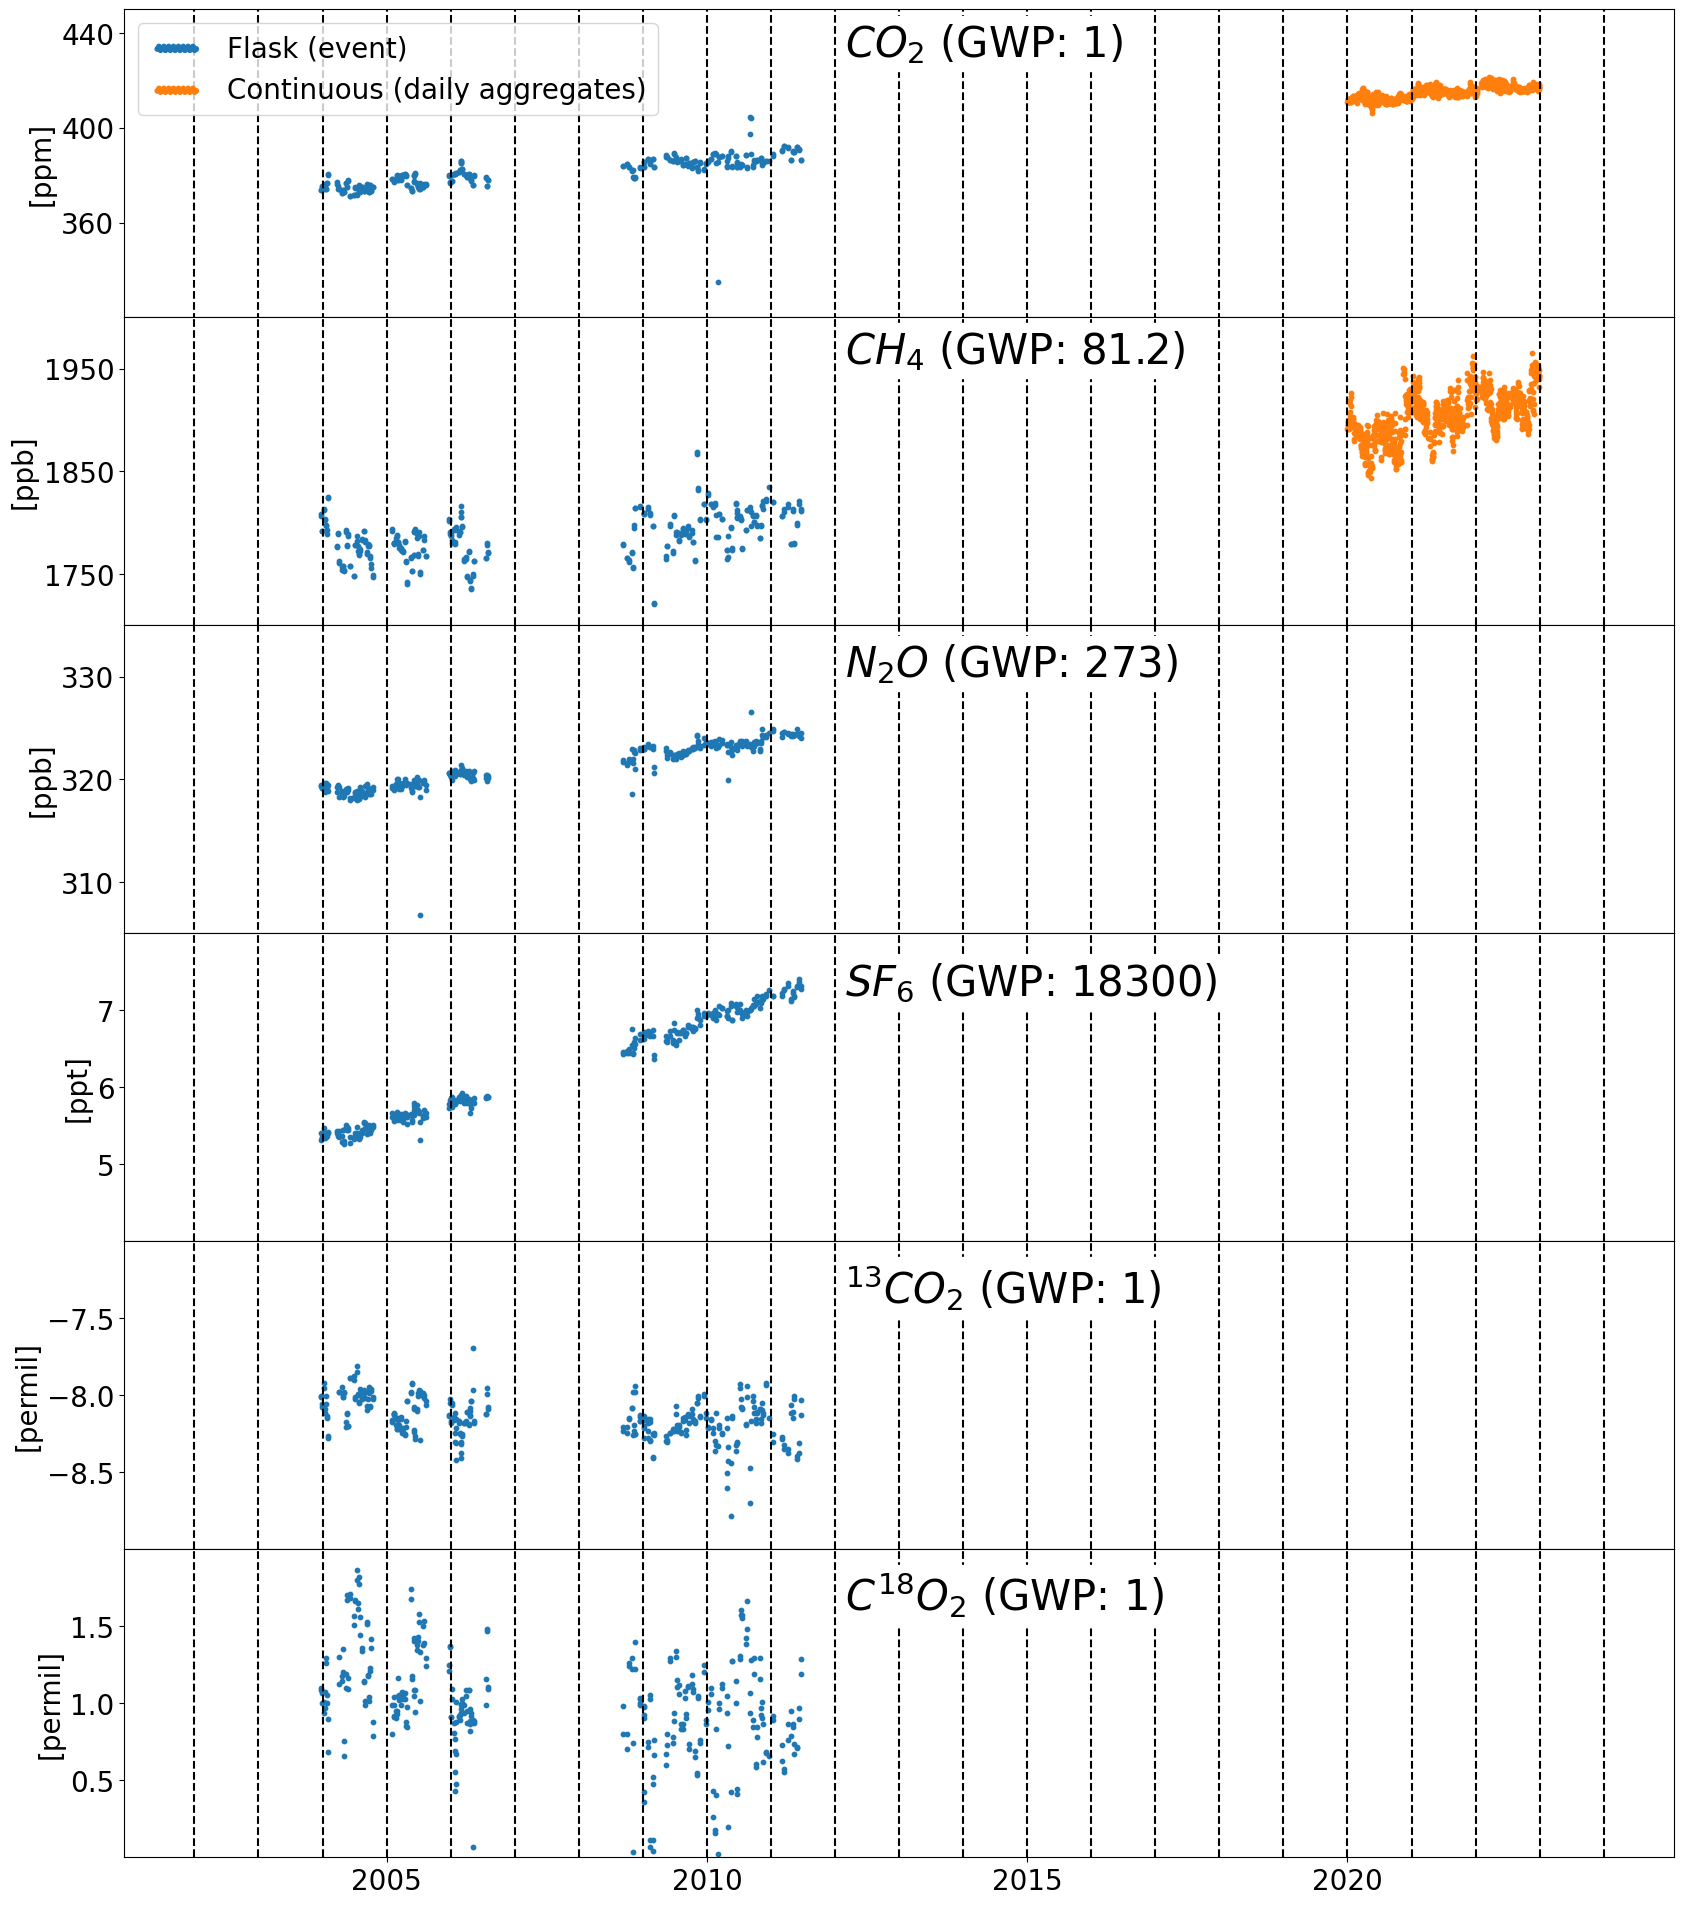

In [3]:
# Make Plot 

fig = plt.figure(figsize=(20,24))
plt.subplots_adjust(hspace=0)
ax1 = plt.subplot(611)
ax2 = plt.subplot(612)
ax3 = plt.subplot(613)
ax4 = plt.subplot(614)
ax5 = plt.subplot(615)
ax6 = plt.subplot(616)

# xlabel
x_dates = []
for y in range(2002,2025):
    x_dates.append(str(y)+"-01-01")

#### CO2 ####
ax1.scatter(df["CO2_event"]["date"], df["CO2_event"]["value"], marker="o", s= 10, label="Flask (event)")
ax1.scatter(df["CO2_daily"]["date"], df["CO2_daily"]["value"], marker="o", s= 10, label="Continuous (daily aggregates)")
ax1.set_ylim(320,450)
ax1.set_ylabel("[ppm]", fontsize=20)
ax1.tick_params(axis="y", labelsize=20)
ax1.vlines(x = x_dates, ymin=300, ymax=460, colors="k", ls="--")
ax1.set_yticks([360,400,440])
ax1.legend(loc="upper left", fontsize=20, scatterpoints=25)
t = ax1.text(15400, 430, "$CO_{2}$ (GWP: 1)", fontsize=30) # GWP: Global Warming Potential according to IPCC AR6
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))

#### CH4 ####
ax2.scatter(df["CH4_event"]["date"], df["CH4_event"]["value"], marker="o", s= 10, label="Flask (event)")
ax2.scatter(df["CH4_daily"]["date"], df["CH4_daily"]["value"], marker="o", s= 10, label="Continuous (daily aggregates)")
ax2.set_ylim(1700,2000)
ax2.set_ylabel("[ppb]", fontsize=20)
ax2.vlines(x = x_dates, ymin=1700, ymax=2000, colors="k", ls="--")
ax2.set_yticks([1750,1850, 1950])
t = ax2.text(15400, 1955, "$CH_{4}$ (GWP: 81.2)", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax2.tick_params(axis="y", labelsize=20)

#### N2O ####
ax3.scatter(df["N2O_event"]["date"], df["N2O_event"]["value"], marker="o", s= 10, label="Flask (event)")
ax3.set_ylim(305,335)
ax3.set_ylabel("[ppb]", fontsize=20)
ax3.vlines(x = x_dates, ymin=300, ymax=340, colors="k", ls="--")
ax3.set_yticks([310,320, 330])
t = ax3.text(15400, 330, "$N_2O$ (GWP: 273)", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax3.set_xticks(["2005","2010", "2015", "2020"], ["2005","2010", "2015", "2020"])
ax3.tick_params(axis="y", labelsize=20)

#### SF6 ####
ax4.scatter(df["SF6_event"]["date"], df["SF6_event"]["value"], marker="o", s= 10, label="Flask (event)")
ax4.set_ylim(4,8)
ax4.set_ylabel("[ppt]", fontsize=20)
ax4.vlines(x = x_dates, ymin=4, ymax=8, colors="k", ls="--")
ax4.set_yticks([5,6,7])
t = ax4.text(15400, 7.2, "$SF_6$ (GWP: 18300)", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax4.tick_params(axis="y", labelsize=20)

#### 13CO2 ####
ax5.scatter(df["13CO2_event"]["date"], df["13CO2_event"]["value"], marker="o", s= 10, label="Flask (event)")
ax5.set_ylim(-9,-7)
ax5.set_ylabel("[permil]", fontsize=20)
ax5.vlines(x = x_dates, ymin=-9, ymax=-7, colors="k", ls="--")
ax5.set_yticks([-8.5,-8,-7.5])
t = ax5.text(15400, -7.4, "$^{13}CO_2$ (GWP: 1)", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax5.tick_params(axis="y", labelsize=20)

#### C18O2 ####
ax6.scatter(df["C18O2_event"]["date"], df["C18O2_event"]["value"], marker="o", s= 10, label="Flask (event)")
ax6.set_ylim(0,2)
ax6.set_ylabel("[permil]", fontsize=20)
ax6.vlines(x = x_dates, ymin=0, ymax=3, colors="k", ls="--")
ax6.set_yticks([0.5,1,1.5])
t = ax6.text(15400, 1.6, "$C^{18}O_2$ (GWP: 1)", fontsize=30)
t.set_bbox(dict(facecolor='white', alpha=1, edgecolor='white'))
ax6.set_xticks(["2005","2010", "2015", "2020"], ["2005","2010", "2015", "2020"])
ax6.tick_params(axis="y", labelsize=20)
ax6.tick_params(axis="x", labelsize=20)


# save figure
#fig.savefig(os.getcwd()+"/results/plots/Greenhouse_gases.jpeg", bbox_inches='tight')